<div style="text-align:center;">

# Actividad 5 | Visualización de Resultados

### Validación cruzada *k*-fold y visualización del mejor modelo sobre Big Data (PySpark)

**Tecnológico de Monterrey** · Maestría en Inteligencia Artificial Aplicada
**TC4034 — Análisis de Grandes Volúmenes de Datos · Módulo 6 (Semanas 9 y 10)**

**Caso de estudio:** NYC TLC *Yellow Taxi Trip Records* 2024

**Entregable:** Visualización_Equipo61 · **Modalidad:** En equipo · **Fecha:** 21 de junio de 2026

| Integrantes — Equipo 61 | Matrícula |
|---|---|
| Eduardo Ramos Hernández | A01797393 |
| Diana Gabriela Ramírez Moreno | A01630769 |
| Oscar Ramírez Anaya | A01795438 |
| Emmanuel Francisco Ramírez Hernández | A01796289 |

**Profesor:** Dr. Iván Olmos Pineda

</div>

---

> **Nota de cómputo.** Este cuaderno se ejecuta sobre **Apache Spark (PySpark MLlib)** en modo local
> (`local[*]`). El mismo pipeline escala sin cambios a un clúster **GCP Dataproc** leyendo la base global
> completa desde Cloud Storage (`gs://…`). El parámetro `MESES` controla cuántos meses de 2024 se procesan
> localmente (por defecto los **12**); la metodología es idéntica a cualquier escala.

## Contexto y objetivo

Esta actividad pertenece al curso *Análisis de Grandes Volúmenes de Datos*. El *Big Data* se caracteriza
por las **V**: **Volumen**, **Velocidad**, **Variedad**, **Veracidad** y **Valor**. Sobre los **viajes en
taxi amarillo de Nueva York (NYC TLC) 2024** se retoma el mejor modelo de la **Actividad 4** —un
`RandomForestClassifier` que predice si un viaje deja **propina alta** (`tip_alta`)— y se responde una
pregunta que una sola partición *train/test* **no** puede contestar: **¿cuánta variabilidad** tienen sus
métricas y **qué tan bien generaliza**.

La herramienta es la **validación cruzada *k*-fold estratificada**: se entrena y evalúa el modelo *k*
veces sobre particiones disjuntas y representativas, y se **comunican los resultados con visualizaciones**
—gráficas de **dispersión**, de **tendencia central**, **mapas de calor**, **curvas ROC/PR**, calibración,
curva de aprendizaje y más— acompañadas de **tablas** y de su interpretación.

**Continuidad.** Se reutilizan las **variables de caracterización** (`tipo_dia × zona_origen × tipo_pago`
→ **12 estratos**) y la **estrategia de muestreo estratificado** del Módulo 3, y la **muestra M** y el
**mejor modelo** de la Actividad 4. La tarea supervisada se restringe a viajes con **tarjeta** (la propina
solo se captura electrónicamente).

### Estructura del cuaderno

| Sección | Contenido |
|---|---|
| **§0 Preparación** | Entorno, datos, capa Silver, 12 estratos y reconstrucción de la muestra **M**. |
| **§1 Definición de la validación cruzada** | Elección y argumentación del valor ***k***. |
| **§2 Construcción de los *k*-folds** | Poblado **estratificado y determinista** de cada pliegue. |
| **§3 Experimentacion** | Entrenamiento del mejor modelo por pliegue y registro de métricas. |
| **§4 Resultados** | Tablas y visualización de la variabilidad y la generalización. |
| **§5 Discusión y conclusiones** | Significancia de los resultados para la tarea planteada. |

## 0. Preparación: entorno, datos y reconstrucción de la muestra M

Antes de las cinco secciones de la rúbrica se reconstruye el flujo validado en las Actividades 3 y 4
(entorno PySpark, ingesta 2024, capa Silver, los 12 estratos del Módulo 3 y la muestra **M** del paso 1
de la Actividad 4). Esto hace el cuaderno **autocontenido y reproducible**.

### 0.1 Entorno PySpark y utilidades de presentación

In [1]:
import os, glob, math, random, time
from functools import reduce

# Java 17 (Homebrew) para el runtime de Spark
os.environ.setdefault("JAVA_HOME",
    "/opt/homebrew/Cellar/openjdk@17/17.0.17/libexec/openjdk.jdk/Contents/Home")

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML

# --- Estilo visual corporativo (TEC) y de tablas ---
TEC_BLUE = "#0054A6"; TEC_RED = "#E03E2D"; TEC_GREEN = "#2E8B57"; TEC_GRAY = "#545454"
sns.set_theme(style="whitegrid", context="notebook")
matplotlib.rcParams["font.family"] = "DejaVu Sans"     # soporte de acentos UTF-8
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 96
plt.rcParams["savefig.dpi"] = 96
pd.set_option("display.precision", 4)

_TH = [{"selector": "th",
        "props": [("background-color", TEC_BLUE), ("color", "white"),
                  ("font-weight", "bold"), ("text-align", "center"), ("padding", "6px 10px")]},
       {"selector": "td", "props": [("padding", "5px 10px")]},
       {"selector": "caption",
        "props": [("caption-side", "top"), ("font-weight", "bold"),
                  ("font-size", "1.02em"), ("color", "#222"), ("padding", "6px")]}]

def tabla(df, caption=None, precision=4, cmap=None, subset=None):
    "Renderiza un DataFrame como tabla HTML profesional (no print monoespaciado)."
    sty = (df.style.format(precision=precision).set_table_styles(_TH))
    if caption:
        sty = sty.set_caption(caption)
    if cmap is not None:
        sty = sty.background_gradient(cmap=cmap, subset=subset, axis=None)
    display(sty)

spark = (SparkSession.builder
         .master("local[*]")
         .appName("M6_Act5_VisualizacionResultados_Equipo61")
         .config("spark.sql.parquet.mergeSchema", "false")
         .config("spark.sql.adaptive.enabled", "true")
         .config("spark.driver.memory", "6g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
print("PySpark", spark.version, "| semilla global SEED =", SEED)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/21 11:28:58 WARN Utils: Your hostname, MacBook-Pro-de-Oscar.local, resolves to a loopback address: 127.0.0.1; using 192.168.100.47 instead (on interface en0)
26/06/21 11:28:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/21 11:28:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


PySpark 4.1.1 | semilla global SEED = 42


### 0.2 Ingesta del dataset 2024 y esquema canónico

**Procedencia y pertinencia del dato.** El conjunto **NYC TLC *Yellow Taxi Trip Records* 2024** es un
registro administrativo de dominio público publicado por la *Taxi & Limousine Commission* de la ciudad de
Nueva York. Es un caso paradigmático de *Big Data* por sus **V**: **Volumen** (decenas de millones de
viajes/año), **Variedad** (numéricas, temporales y categóricas geográficas), **Veracidad** (requiere una
capa de limpieza, §0.3) y **Valor** (permite estudiar patrones de movilidad y de pago). La **población P**
es el universo de viajes 2024; su materialización en Parquet es la **base global D**. Trabajar sobre una
**muestra representativa M** —y no sobre D completa en cada experimento— es precisamente la estrategia que
hace **viable y económica** la validación cruzada sobre Big Data.

**Reto técnico de ingesta.** Cada registro es **un viaje**. Los Parquet oficiales de 2024 presentan
**heterogeneidad de tipos** entre meses (`RatecodeID`, `passenger_count`, `congestion_surcharge`,
`airport_fee` oscilan INT64/DOUBLE); unir los archivos sin tratarlos provocaría errores de esquema. Por
ello se **normaliza** cada archivo a un **esquema canónico** explícito y se unen con `unionByName`. El
parámetro `MESES` decide cuántos meses se procesan (por defecto **todos los disponibles localmente**).

**Diccionario de variables (columnas relevantes)**

| Columna | Significado | Uso |
|---|---|---|
| `tpep_pickup_datetime` / `tpep_dropoff_datetime` | Inicio / fin del viaje | Duración, hora, día |
| `trip_distance` | Distancia (millas) | Feature |
| `PULocationID` | Zona TLC de origen | `zona_origen` |
| `payment_type` | Método de pago (1 = tarjeta) | Filtro tarjeta + estrato |
| `fare_amount` | Tarifa base | Feature y denominador de `tip_alta` |
| `tip_amount` | **Propina** (solo con tarjeta) | **Define la etiqueta** `tip_alta` |
| `total_amount` | Total cobrado | **Excluida (fuga de datos)** |

> **Etiqueta.** `tip_alta = 1` si `tip_amount / fare_amount > 0.20`. **Fuga de datos:** se excluyen
> `payment_type`, `tip_amount` y `total_amount` de las características del modelo.

In [2]:
# Esquema canonico (resuelve la heterogeneidad INT64/DOUBLE entre meses de 2024)
TARGET_TYPES = {
    "VendorID":"bigint", "tpep_pickup_datetime":"timestamp", "tpep_dropoff_datetime":"timestamp",
    "passenger_count":"double", "trip_distance":"double", "RatecodeID":"double",
    "store_and_fwd_flag":"string", "PULocationID":"bigint", "DOLocationID":"bigint",
    "payment_type":"bigint", "fare_amount":"double", "extra":"double", "mta_tax":"double",
    "tip_amount":"double", "tolls_amount":"double", "improvement_surcharge":"double",
    "total_amount":"double", "congestion_surcharge":"double", "airport_fee":"double",
}

CARPETAS = ["data/yellow_2024", "../actividad_3_aprendizaje_supervisado/data/yellow_2024"]
CARPETA = next((c for c in CARPETAS if glob.glob(c + "/yellow_tripdata_2024-*.parquet")), CARPETAS[0])
archivos = sorted(glob.glob(CARPETA + "/yellow_tripdata_2024-*.parquet"))
print(f"Carpeta de datos: {CARPETA}  |  meses encontrados: {len(archivos)}")

def leer_y_normalizar(path):
    d = spark.read.parquet(path)
    exprs = [F.col(c).cast(t).alias(c) if c in d.columns else F.lit(None).cast(t).alias(c)
             for c, t in TARGET_TYPES.items()]
    return d.select(*exprs)

df = reduce(lambda a, b: a.unionByName(b), [leer_y_normalizar(p) for p in archivos]).cache()
TOTAL = df.count()
print(f"Base global D (local, {len(archivos)} meses): {TOTAL:,} registros crudos")

Carpeta de datos: data/yellow_2024  |  meses encontrados: 12


Base global D (local, 12 meses): 41,169,720 registros crudos


In [3]:
# Vista previa (tabla) de algunos registros
display(df.select("tpep_pickup_datetime","trip_distance","PULocationID","payment_type",
                  "fare_amount","tip_amount","total_amount").limit(5).toPandas())

,tpep_pickup_datetime,trip_distance,PULocationID,payment_type,fare_amount,tip_amount,total_amount
0,2024-01-01 00:57:55,1.72,186,2,17.7,0.00,22.70
1,2024-01-01 00:03:00,1.80,140,1,10.0,3.75,18.75
2,2024-01-01 00:17:06,4.70,236,1,23.3,3.00,31.30
3,2024-01-01 00:36:38,1.40,79,1,10.0,2.00,17.00
4,2024-01-01 00:46:51,0.80,211,1,7.9,3.20,16.10


### 0.3 Capa Silver y los 12 estratos del Módulo 3

Se aplican los **filtros de calidad** de la Actividad 3 (tarifas y distancias positivas, distancia < 200
mi, orden temporal correcto, tarifa válida, claves no nulas, año 2024) y se generan las tres **variables
de caracterización** que definen los estratos: `tipo_dia × zona_origen × tipo_pago`.

In [4]:
df_silver = (df
    .filter(F.col("fare_amount") > 0)
    .filter(F.col("trip_distance") > 0)
    .filter(F.col("trip_distance") < 200)
    .filter(F.col("tpep_pickup_datetime") < F.col("tpep_dropoff_datetime"))
    .filter((F.col("RatecodeID").isNull()) | (F.col("RatecodeID") != 99))
    .filter(F.col("PULocationID").isNotNull())
    .filter(F.col("payment_type").isNotNull())
    .filter(F.year("tpep_pickup_datetime") == 2024))
N_SILVER = df_silver.count()
print(f"Capa Silver: {N_SILVER:,} registros  ({(1-N_SILVER/TOTAL)*100:.2f}% descartado)")

Capa Silver: 39,263,800 registros  (4.63% descartado)


In [5]:
# Zonas TLC (IDs oficiales) para la variable zona_origen
manhattan_ids = [4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79, 87, 88, 90,
                 100, 103, 104, 105, 107, 113, 114, 116, 120, 125, 127, 128, 137, 140,
                 141, 142, 143, 144, 148, 151, 152, 153, 158, 161, 162, 163, 164, 166,
                 170, 186, 194, 202, 209, 211, 224, 229, 230, 231, 232, 233, 234, 236,
                 237, 238, 239, 243, 244, 246, 249, 261, 262, 263]
aeropuerto_ids = [1, 132, 138]   # Newark, JFK, LaGuardia

df_part = (df_silver
    .withColumn("tipo_dia",
        F.when(F.dayofweek("tpep_pickup_datetime").isin([1, 7]), "Finde").otherwise("Laborable"))
    .withColumn("zona_origen",
        F.when(F.col("PULocationID").isin(aeropuerto_ids), "Aeropuerto")
         .when(F.col("PULocationID").isin(manhattan_ids),  "Manhattan").otherwise("Otros"))
    .withColumn("tipo_pago",
        F.when(F.col("payment_type") == 1, "Tarjeta").otherwise("NoTarjeta"))
    .withColumn("particion_id",
        F.concat_ws("|", F.col("tipo_dia"), F.col("zona_origen"), F.col("tipo_pago")))).cache()
part_counts = {r["particion_id"]: r["count"]
               for r in df_part.groupBy("particion_id").count().collect()}

estratos_tab = (pd.DataFrame([{"estrato": k, "n_D": v} for k, v in part_counts.items()])
                .assign(proporcion=lambda d: d.n_D / N_SILVER)
                .sort_values("n_D", ascending=False).reset_index(drop=True))
print(f"Estratos reconstruidos: {len(part_counts)}")
tabla(estratos_tab, caption="Tamaño de cada estrato en la capa Silver (D)",
      cmap="Blues", subset=["n_D", "proporcion"])

Estratos reconstruidos: 12


,estrato,n_D,proporcion
0,Laborable|Manhattan|Tarjeta,19598574,0.4992
1,Finde|Manhattan|Tarjeta,7245038,0.1845
2,Laborable|Manhattan|NoTarjeta,5728077,0.1459
3,Finde|Manhattan|NoTarjeta,2561052,0.0652
4,Laborable|Aeropuerto|Tarjeta,1812249,0.0462
5,Finde|Aeropuerto|Tarjeta,673092,0.0171
6,Laborable|Aeropuerto|NoTarjeta,473365,0.0121
7,Laborable|Otros|NoTarjeta,329857,0.0084
8,Laborable|Otros|Tarjeta,290836,0.0074
9,Finde|Otros|NoTarjeta,248146,0.0063


### 0.4 Reconstrucción de la muestra M (paso 1 de la Actividad 4)

Se reconstruye **M** con el criterio de la Actividad 4: tamaño justificado por **Cochran (1977)** con
**corrección por población finita (FPC)**, **asignación proporcional** por estrato con un **piso** de
salvaguarda, y **muestreo sistemático intra-estrato** ordenado por `tpep_pickup_datetime` (técnica del
Módulo 3). Sobre M se derivan las variables de modelado y la etiqueta `tip_alta`.

In [6]:
# Tamano de muestra (Cochran + FPC): p=0.5 (varianza maxima), z=1.96 (95%), e=0.01 (+/-1%)
Z, p_var, e = 1.96, 0.5, 0.01
n0    = (Z**2 * p_var * (1 - p_var)) / (e**2)
n_min = math.ceil(n0 / (1 + (n0 - 1) / N_SILVER))
N_MUESTRA = 80_000
print(f"n minimo (FPC, 95%, +/-1%) = {n_min:,}   |   n de trabajo M = {N_MUESTRA:,}")

# Asignacion proporcional por estrato con piso de salvaguarda
PISO = 200
cuotas = {pid: min(cnt, max(PISO, math.ceil(N_MUESTRA * cnt / N_SILVER)))
          for pid, cnt in part_counts.items()}

# Muestreo sistematico intra-estrato ordenado por fecha de pickup (reproducible)
w = Window.partitionBy("particion_id").orderBy("tpep_pickup_datetime")
df_rn = df_part.withColumn("rn", F.row_number().over(w))
saltos    = {pid: max(1, part_counts[pid] // cuotas[pid]) for pid in part_counts}
arranques = {pid: random.randint(0, saltos[pid] - 1)      for pid in part_counts}
cond = F.lit(False)
for pid in part_counts:
    k_step, r0, ni = saltos[pid], arranques[pid], cuotas[pid]
    cond = cond | ((F.col("particion_id") == pid) &
        (((F.col("rn") - F.lit(1 + r0)) % F.lit(k_step)) == 0) &
        (F.col("rn") <= F.lit(r0 + 1 + k_step * (ni - 1))))
M = df_rn.filter(cond).drop("rn").cache()
N_M0 = M.count()
print(f"Tamano de la muestra M: {N_M0:,} registros")

n minimo (FPC, 95%, +/-1%) = 9,602   |   n de trabajo M = 80,000


Tamano de la muestra M: 80,006 registros


In [7]:
# Verificacion de representatividad: proporciones por estrato en D vs en M (desviacion maxima ~ 0)
m_counts = {r["particion_id"]: r["count"] for r in M.groupBy("particion_id").count().collect()}
rep = (estratos_tab[["estrato","n_D","proporcion"]].rename(columns={"proporcion":"P_D"})
       .assign(n_M=lambda d: d.estrato.map(m_counts).fillna(0).astype(int))
       .assign(P_M=lambda d: d.n_M / N_M0)
       .assign(abs_err=lambda d: (d.P_D - d.P_M).abs())
       .sort_values("n_D", ascending=False).reset_index(drop=True))
tabla(rep[["estrato","n_D","n_M","P_D","P_M","abs_err"]],
      caption="Representatividad: proporción por estrato en D vs M", cmap="Blues", subset=["abs_err"])
print(f"Desviación máxima |P_D - P_M| = {rep['abs_err'].max():.4f}  (≈ 0 ⇒ M es representativa de D)")

,estrato,n_D,n_M,P_D,P_M,abs_err
0,Laborable|Manhattan|Tarjeta,19598574,39933,0.4992,0.4991,0.0000
1,Finde|Manhattan|Tarjeta,7245038,14762,0.1845,0.1845,0.0000
2,Laborable|Manhattan|NoTarjeta,5728077,11671,0.1459,0.1459,0.0000
3,Finde|Manhattan|NoTarjeta,2561052,5219,0.0652,0.0652,0.0000
4,Laborable|Aeropuerto|Tarjeta,1812249,3693,0.0462,0.0462,0.0000
5,Finde|Aeropuerto|Tarjeta,673092,1372,0.0171,0.0171,0.0000
6,Laborable|Aeropuerto|NoTarjeta,473365,965,0.0121,0.0121,0.0000
7,Laborable|Otros|NoTarjeta,329857,673,0.0084,0.0084,0.0000
8,Laborable|Otros|Tarjeta,290836,593,0.0074,0.0074,0.0000
9,Finde|Otros|NoTarjeta,248146,506,0.0063,0.0063,0.0000


Desviación máxima |P_D - P_M| = 0.0000  (≈ 0 ⇒ M es representativa de D)


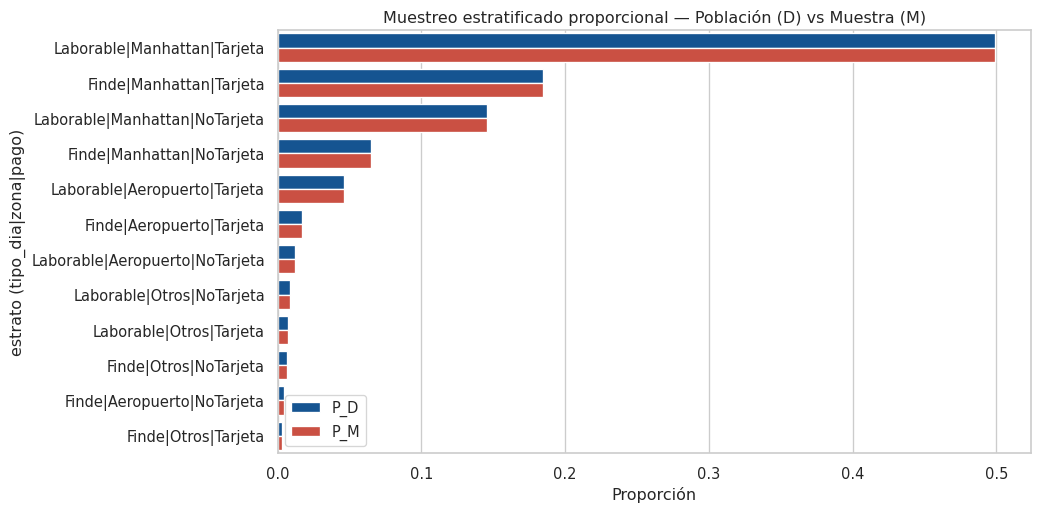

In [8]:
# Visualizacion de la representatividad del muestreo (D vs M)
comp = rep.melt(id_vars="estrato", value_vars=["P_D","P_M"], var_name="origen", value_name="prop")
plt.figure(figsize=(11, 5.5))
sns.barplot(data=comp, y="estrato", x="prop", hue="origen", palette=[TEC_BLUE, TEC_RED])
plt.title("Muestreo estratificado proporcional — Población (D) vs Muestra (M)")
plt.xlabel("Proporción"); plt.ylabel("estrato (tipo_dia|zona|pago)")
plt.legend(title=""); plt.tight_layout(); plt.show()

In [9]:
# Variables derivadas, imputacion, tope de propina (P99) y etiqueta binaria tip_alta
M2 = (M
    .withColumn("trip_duration_min",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60.0)
    .withColumn("pickup_hour",  F.hour("tpep_pickup_datetime"))
    .withColumn("pickup_dow",   F.dayofweek("tpep_pickup_datetime"))
    .withColumn("pickup_month", F.month("tpep_pickup_datetime"))
    .fillna({"passenger_count": 1, "congestion_surcharge": 0.0, "airport_fee": 0.0})
    .filter(F.col("trip_duration_min") > 0)
    .filter(F.col("trip_duration_min") < 180))
p99 = M2.approxQuantile("tip_amount", [0.99], 0.01)[0]
M2 = (M2.withColumn("tip_amount", F.when(F.col("tip_amount") > p99, p99).otherwise(F.col("tip_amount")))
        .withColumn("tip_alta", F.when(F.col("tip_amount") / F.col("fare_amount") > 0.20, 1).otherwise(0)))

# Tarea supervisada: SOLO tarjeta (la propina solo se captura electronicamente con tarjeta)
sup = M2.filter(F.col("tipo_pago") == "Tarjeta").cache()
df_part.unpersist()
N_SUP = sup.count()
prev0 = sup.agg(F.avg("tip_alta")).first()[0]
print(f"Poblacion supervisada (solo tarjeta) en M: {N_SUP:,} registros | prevalencia tip_alta=1: {prev0:.4f}")
display(sup.groupBy("tip_alta").count().orderBy("tip_alta").toPandas())

Poblacion supervisada (solo tarjeta) en M: 60,574 registros | prevalencia tip_alta=1: 0.7581


,tip_alta,count
0,0,14653
1,1,45921


## 1. Definición del proceso de validación cruzada

### 1.1 Objetivo de la validación cruzada en este proyecto

La Actividad 4 identificó al `RandomForestClassifier` (restringido a tarjeta) como el **mejor modelo** y
estableció **AUC-ROC** y **AUC-PR** como métricas principales. Lo que **una sola partición *train/test* no
mide** es la **variabilidad** de esas métricas: una estimación puntual puede ser optimista o pesimista por
azar de la partición. La **validación cruzada *k*-fold** entrena y evalúa el modelo *k* veces sobre
particiones disjuntas, produciendo una **distribución** de cada métrica (media ± desviación) y permitiendo
**detectar sobre-ajuste** al comparar train vs. test en cada pliegue.

### 1.2 Elección y argumentación del valor *k*

Se elige **k = 5**. La decisión es **multidimensional**:

| Dimensión | Criterio | Implicación para *k* |
|---|---|---|
| **Sesgo–varianza** (Kohavi, 1995) | *k* chico → sesgo (pesimista); *k* grande (LOO) → varianza y costo | **k = 5** equilibra (entrena 80 %, evalúa 20 %) |
| **Representatividad por pliegue** | la estratificación mantiene la composición; el estrato más chico debe sobrevivir | con *k = 5* cada pliegue conserva más instancias del estrato raro que con *k = 10* |
| **Costo en Big Data** (Junqué de Fortuny et al., 2013) | cada pliegue = un entrenamiento completo | *k = 5* hace **5** entrenamientos vs **10** de *k = 10* |

> **Alternativas.** *k = 3* es más económico pero más sesgado; *k = 10* y la **validación cruzada
> repetida** reducen varianza a mayor costo. Para decenas de millones de registros, **k = 5** ofrece el
> mejor compromiso *sesgo–varianza–costo*. La tabla siguiente lo verifica numéricamente.

In [10]:
# Comparativa del trade-off entre valores de k
sup_counts = {r["particion_id"]: r["count"]
              for r in sup.groupBy("particion_id").count().collect()}
min_pid = min(sup_counts, key=sup_counts.get)
n_min_estrato = sup_counts[min_pid]

tabla_k = pd.DataFrame([
    {"k": k, "entrenamientos": k, "% train por pliegue": round(100*(k-1)/k, 1),
     "instancias del estrato más pequeño por pliegue": n_min_estrato // k,
     "perfil": {3: "más sesgo, más barato", 5: "equilibrio (elegido)",
                10: "menos sesgo, más costo/varianza"}[k]}
    for k in [3, 5, 10]])
print(f"Estrato de tarjeta más pequeño: '{min_pid}' con {n_min_estrato:,} registros")
tabla(tabla_k, caption="Trade-off del valor de k (representatividad vs costo)", precision=1)

K = 5
print(f"Valor elegido: k = {K}")

Estrato de tarjeta más pequeño: 'Finde|Otros|Tarjeta' con 259 registros


,k,entrenamientos,% train por pliegue,instancias del estrato más pequeño por pliegue,perfil
0,3,3,66.7,86,"más sesgo, más barato"
1,5,5,80.0,51,equilibrio (elegido)
2,10,10,90.0,25,"menos sesgo, más costo/varianza"


Valor elegido: k = 5


## 2. Construcción de los *k*-folds

Cada pliegue se construye con un reparto **estratificado y determinista** que reproduce la técnica del
Módulo 3:

1. La **llave de estrato** es `particion_id × tip_alta` (caracterización dentro de tarjeta × clase
   objetivo), para conservar tanto la mezcla de estratos como el **balance de clases**.
2. Dentro de cada estrato, las instancias se ordenan por una **llave hash determinista** (`xxhash64` del
   contenido del viaje + semilla) y se asigna el pliegue con `row_number() % k`. A diferencia de `rand()`,
   esto es **100 % reproducible** entre ejecuciones.
3. Se **verifica** que los pliegues sean **disjuntos y exhaustivos**, de tamaño equilibrado y
   representativos en clase y en composición de estratos.

In [11]:
# Asignacion ESTRATIFICADA y DETERMINISTA del numero de pliegue (reproducible, sin rand())
hash_key = F.xxhash64(
    F.col("tpep_pickup_datetime").cast("string"), F.col("PULocationID").cast("string"),
    F.col("DOLocationID").cast("string"), F.col("fare_amount").cast("string"),
    F.col("trip_distance").cast("string"), F.lit(SEED))
wf = Window.partitionBy("particion_id", "tip_alta").orderBy(hash_key)
sup_folds = (sup.withColumn("fold", (F.row_number().over(wf) % F.lit(K)).cast("int"))
                .repartition(8).cache())
N_FOLDS_TOTAL = sup_folds.count()

tam = sup_folds.groupBy("fold").count().orderBy("fold").toPandas()
tabla(tam, caption="Tamaño de cada pliegue", precision=0)

,fold,count
0,0,12109
1,1,12118
2,2,12118
3,3,12115
4,4,12114


In [12]:
# Verificacion 1: pliegues DISJUNTOS y EXHAUSTIVOS
suma_folds = int(tam["count"].sum())
valores_fold = sorted(tam["fold"].tolist())
assert suma_folds == N_SUP == N_FOLDS_TOTAL, "La union de pliegues no reconstruye la poblacion"
assert valores_fold == list(range(K)), "Hay numeros de pliegue fuera de 0..k-1"
print(f"OK: {K} pliegues disjuntos y exhaustivos | suma = {suma_folds:,} = |poblacion| = {N_SUP:,}")

# Verificacion 2: balance de la clase tip_alta por pliegue (debe ser ~constante)
bal_fold = (sup_folds.groupBy("fold")
            .agg(F.round(F.avg("tip_alta"), 4).alias("prop_tip_alta_1"), F.count("*").alias("n"))
            .orderBy("fold").toPandas())
tabla(bal_fold, caption="Balance de la clase tip_alta=1 por pliegue (estratificación en clase)")

OK: 5 pliegues disjuntos y exhaustivos | suma = 60,574 = |poblacion| = 60,574


,fold,prop_tip_alta_1,n
0,0,0.7583,12109
1,1,0.7580,12118
2,2,0.7580,12118
3,3,0.7581,12115
4,4,0.7580,12114


In [13]:
# Verificacion 3: composicion (%) de cada pliegue por estrato de caracterizacion
piv = (sup_folds.groupBy("particion_id", "fold").count()
       .groupBy("particion_id").pivot("fold").sum("count").fillna(0).toPandas()
       .set_index("particion_id").sort_index())
piv_pct = (piv.div(piv.sum(axis=0), axis=1) * 100).round(2)
piv_pct.columns = [f"pliegue {c}" for c in piv_pct.columns]
tabla(piv_pct, caption="Composición (%) de cada pliegue por estrato (columnas ~ idénticas)",
      precision=2, cmap="Blues")

,pliegue 0,pliegue 1,pliegue 2,pliegue 3,pliegue 4
particion_id,,,,,
Finde|Aeropuerto|Tarjeta,2.25,2.27,2.27,2.26,2.26
Finde|Manhattan|Tarjeta,24.36,24.35,24.35,24.36,24.36
Finde|Otros|Tarjeta,0.42,0.43,0.43,0.43,0.43
Laborable|Aeropuerto|Tarjeta,6.09,6.10,6.10,6.08,6.08
Laborable|Manhattan|Tarjeta,65.91,65.87,65.87,65.89,65.88
Laborable|Otros|Tarjeta,0.97,0.98,0.98,0.98,0.98


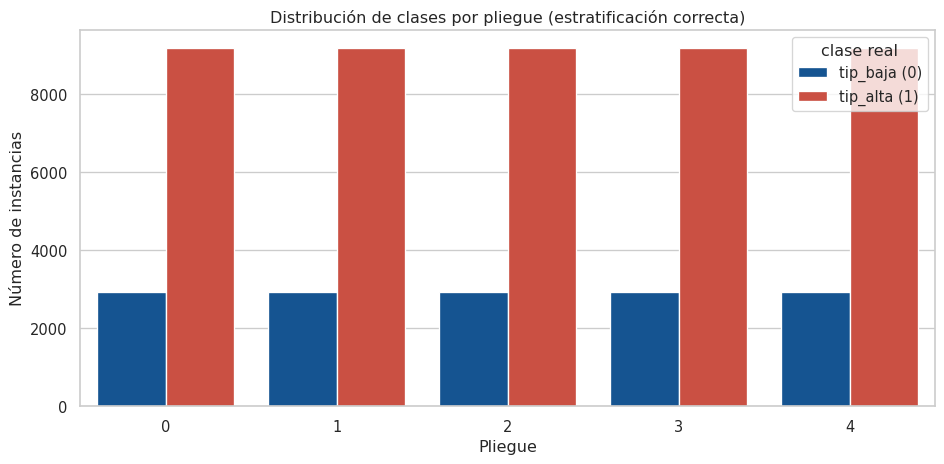

In [14]:
# Visualizacion: distribucion de clases por pliegue (verificacion grafica de la estratificacion)
cls = (sup_folds.groupBy("fold","tip_alta").count().orderBy("fold","tip_alta").toPandas())
cls["clase"] = cls["tip_alta"].map({0:"tip_baja (0)", 1:"tip_alta (1)"})
plt.figure(figsize=(10, 5))
sns.barplot(data=cls, x="fold", y="count", hue="clase", palette=[TEC_BLUE, TEC_RED])
plt.title("Distribución de clases por pliegue (estratificación correcta)")
plt.xlabel("Pliegue"); plt.ylabel("Número de instancias"); plt.legend(title="clase real")
plt.tight_layout(); plt.show()

## 3. Experimentacion

Se entrena el **mejor algoritmo de la Actividad 4** —`RandomForestClassifier` (`numTrees=50`,
`maxDepth=8`)— bajo el esquema de validación cruzada de 5 pliegues. Para cada pliegue *f*: entrenamiento
con los 4 pliegues restantes y prueba con el retenido; se registran AUC-ROC y AUC-PR (cálculo
**distribuido** en `pyspark.ml`), métricas **binarias por clase** (precisión, *recall*, F1, MCC, Balanced
Accuracy), la **brecha train–test** (sobre-ajuste), el **tiempo** y las **predicciones**.

### 3.1 Catálogo de métricas (selección de la Actividad 4)

| Métrica | Qué mide | Por qué aquí |
|---|---|---|
| **AUC-ROC** | Capacidad de *ranking* global | Métrica principal, independiente del umbral |
| **AUC-PR** | *Ranking* enfocado en la clase positiva | La más informativa bajo desbalance |
| **F1 (clase 1)** | Balance precisión/recall de `tip_alta` | Robusta al desbalance |
| **MCC** | Correlación binaria global | La más robusta con clases desbalanceadas |
| **Balanced Accuracy** | Aciertos promediados por clase | Corrige el sesgo de la *accuracy* |
| **Brecha train−test** | Diferencia de AUC train vs test | **Detecta sobre-ajuste** |

In [15]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.functions import vector_to_array
from pyspark.ml.evaluation import BinaryClassificationEvaluator

cat_cols = ["zona_origen", "tipo_dia"]
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") for c in cat_cols]
num_cols = ["trip_distance", "trip_duration_min", "fare_amount", "tolls_amount",
            "congestion_surcharge", "airport_fee", "passenger_count",
            "pickup_hour", "pickup_dow", "pickup_month"]
assembler = VectorAssembler(inputCols=num_cols + [c+"_ohe" for c in cat_cols],
                            outputCol="features", handleInvalid="skip")

def make_pipeline():
    rf = RandomForestClassifier(featuresCol="features", labelCol="tip_alta",
                                numTrees=50, maxDepth=8, seed=SEED)
    return Pipeline(stages=indexers + encoders + [assembler, rf])

ev_auc = BinaryClassificationEvaluator(labelCol="tip_alta", rawPredictionCol="rawPrediction",
                                       metricName="areaUnderROC")
ev_pr  = BinaryClassificationEvaluator(labelCol="tip_alta", rawPredictionCol="rawPrediction",
                                       metricName="areaUnderPR")

def binarias_desde_pandas(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    tp = int(((yhat==1)&(y==1)).sum()); tn = int(((yhat==0)&(y==0)).sum())
    fp = int(((yhat==1)&(y==0)).sum()); fn = int(((yhat==0)&(y==1)).sum())
    acc  = (tp+tn)/max(tp+tn+fp+fn,1)
    prec = tp/(tp+fp) if tp+fp else 0.0
    rec  = tp/(tp+fn) if tp+fn else 0.0
    spec = tn/(tn+fp) if tn+fp else 0.0
    f1   = 2*prec*rec/(prec+rec) if prec+rec else 0.0
    bal  = (rec+spec)/2
    den  = math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc  = (tp*tn - fp*fn)/den if den else 0.0
    return dict(Accuracy=acc, Precision=prec, Recall=rec, Especificidad=spec,
                F1=f1, Balanced_Acc=bal, MCC=mcc, VP=tp, VN=tn, FP=fp, FN=fn)
print("Pipeline y evaluadores listos.")

Pipeline y evaluadores listos.


In [16]:
# Bucle de validacion cruzada de K pliegues
fold_rows, pred_frames, fi_rows = [], [], []
feat_names = None

t0 = time.time()
for f in range(K):
    train_f = sup_folds.filter(F.col("fold") != f)
    test_f  = sup_folds.filter(F.col("fold") == f)

    tf = time.time()
    model_f = make_pipeline().fit(train_f)
    pr_te = model_f.transform(test_f); pr_tr = model_f.transform(train_f)
    auc_te = ev_auc.evaluate(pr_te); auc_tr = ev_auc.evaluate(pr_tr)
    aupr_te = ev_pr.evaluate(pr_te)

    pdf = (pr_te.withColumn("prob_arr", vector_to_array("probability"))
                .select(F.col("tip_alta").alias("y"), F.col("prob_arr")[1].alias("p"),
                        F.col("prediction").alias("yhat")).toPandas())
    pdf["fold"] = f; pred_frames.append(pdf)

    bm = binarias_desde_pandas(pdf["y"], pdf["yhat"])
    fold_rows.append({"fold": f, "AUC_ROC": auc_te, "AUC_PR": aupr_te, "F1": bm["F1"],
                      "MCC": bm["MCC"], "Balanced_Acc": bm["Balanced_Acc"], "Precision": bm["Precision"],
                      "Recall": bm["Recall"], "Accuracy": bm["Accuracy"],
                      "AUC_ROC_train": auc_tr, "gap_train_test": auc_tr - auc_te,
                      "tiempo_s": time.time() - tf})

    rf_model = model_f.stages[-1]
    fi = rf_model.featureImportances.toArray()
    if feat_names is None:
        attrs = (model_f.transform(train_f.limit(1)).schema["features"]
                 .metadata.get("ml_attr", {}).get("attrs", {}))
        feat_names = [None] * len(fi)
        for grupo in attrs.values():
            for at in grupo:
                feat_names[at["idx"]] = at["name"]
        feat_names = [n if n else f"f_{i}" for i, n in enumerate(feat_names)]
    for nm, imp in zip(feat_names, fi):
        fi_rows.append({"fold": f, "feature": nm, "importance": float(imp)})

    print(f"  Pliegue {f}:  AUC_test={auc_te:.4f}  AUC_PR={aupr_te:.4f}  "
          f"AUC_train={auc_tr:.4f}  brecha={auc_tr-auc_te:+.4f}  ({fold_rows[-1]['tiempo_s']:.1f}s)")

print(f"\nValidacion cruzada de {K} pliegues completada en {time.time()-t0:.1f} s")

  Pliegue 0:  AUC_test=0.5762  AUC_PR=0.8031  AUC_train=0.6169  brecha=+0.0407  (3.5s)


  Pliegue 1:  AUC_test=0.5742  AUC_PR=0.8008  AUC_train=0.6182  brecha=+0.0440  (2.3s)


  Pliegue 2:  AUC_test=0.5885  AUC_PR=0.8074  AUC_train=0.6167  brecha=+0.0282  (2.3s)


  Pliegue 3:  AUC_test=0.5854  AUC_PR=0.8079  AUC_train=0.6161  brecha=+0.0308  (2.2s)


  Pliegue 4:  AUC_test=0.5882  AUC_PR=0.8077  AUC_train=0.6159  brecha=+0.0277  (2.2s)

Validacion cruzada de 5 pliegues completada en 12.5 s


In [17]:
# Consolidacion + tabla de metricas por pliegue
res   = pd.DataFrame(fold_rows).set_index("fold")
preds = pd.concat(pred_frames, ignore_index=True)
fi_df = pd.DataFrame(fi_rows)
metric_cols = ["AUC_ROC", "AUC_PR", "F1", "MCC", "Balanced_Acc", "Precision", "Recall", "Accuracy"]

tabla(res[metric_cols + ["gap_train_test", "tiempo_s"]],
      caption="Métricas por pliegue (conjunto de prueba)", cmap="Greens", subset=metric_cols)

# Baseline trivial (clase mayoritaria) y criterio formal del mejor pliegue
prev = preds["y"].mean()
base_acc = max(prev, 1 - prev)
crit = res.assign(score=res["AUC_PR"] - res["gap_train_test"].abs())
best_fold = int(crit["score"].idxmax())
print(f"Baseline trivial: Accuracy={base_acc:.4f}, AUC-ROC=0.5000, AUC-PR={prev:.4f}")
print(f"Modelo que mejor generaliza: pliegue {best_fold} "
      f"(AUC-PR={res.loc[best_fold,'AUC_PR']:.4f}, AUC-ROC={res.loc[best_fold,'AUC_ROC']:.4f}, "
      f"brecha={res.loc[best_fold,'gap_train_test']:+.4f})")

,AUC_ROC,AUC_PR,F1,MCC,Balanced_Acc,Precision,Recall,Accuracy,gap_train_test,tiempo_s
fold,,,,,,,,,,
0,0.5762,0.8031,0.8624,-0.0089,0.4998,0.7582,0.9997,0.7580,0.0407,3.5239
1,0.5742,0.8008,0.8624,0.0161,0.5002,0.7581,1.0000,0.7581,0.0440,2.2641
2,0.5885,0.8074,0.8623,0.0034,0.5001,0.7581,0.9998,0.7580,0.0282,2.3030
3,0.5854,0.8079,0.8624,0.0000,0.5000,0.7581,1.0000,0.7581,0.0308,2.1836
4,0.5882,0.8077,0.8622,-0.0089,0.4998,0.7580,0.9997,0.7578,0.0277,2.1703


Baseline trivial: Accuracy=0.7581, AUC-ROC=0.5000, AUC-PR=0.7581
Modelo que mejor generaliza: pliegue 4 (AUC-PR=0.8077, AUC-ROC=0.5882, brecha=+0.0277)


## 4. Resultados

Se visualizan los resultados con varias bibliotecas (`matplotlib`, `seaborn` y `plotly` para la vista
interactiva). El repertorio cubre explícitamente los tipos pedidos por el objetivo —**dispersión**,
**tendencia central**, **mapas de calor** y **curvas ROC**— y añade calibración, sensibilidad al umbral,
curva de aprendizaje y ganancia. Bajo cada bloque se interpreta con los **valores reales** obtenidos.

In [18]:
import warnings; warnings.filterwarnings("ignore")
from scipy import stats
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"
PAL = sns.color_palette("viridis", K)

# --- Curvas y matrices en numpy (stack ligero, sin dependencias externas) ---
def roc_np(y, p):
    y = np.asarray(y); p = np.asarray(p); o = np.argsort(-p); y = y[o]
    P = max(int((y==1).sum()),1); N = max(int((y==0).sum()),1)
    tps = np.cumsum(y==1); fps = np.cumsum(y==0)
    tpr = np.concatenate([[0.0], tps/P]); fpr = np.concatenate([[0.0], fps/N])
    a = float(np.sum((fpr[1:]-fpr[:-1])*(tpr[1:]+tpr[:-1])/2.0))
    return fpr, tpr, a

def pr_np(y, p):
    y = np.asarray(y); p = np.asarray(p); o = np.argsort(-p); y = y[o]
    P = max(int((y==1).sum()),1)
    tps = np.cumsum(y==1); fps = np.cumsum(y==0)
    recall = tps/P; precision = tps/np.maximum(tps+fps,1)
    a = float(np.sum((recall[1:]-recall[:-1])*precision[1:]))
    return recall, precision, a

def calib_np(y, p, nbins=10):
    y = np.asarray(y); p = np.asarray(p)
    edges = np.quantile(p, np.linspace(0,1,nbins+1)); edges[0]-=1e-9; edges[-1]+=1e-9
    idx = np.digitize(p, edges)-1; mp=[]; fp=[]
    for b in range(nbins):
        m = idx==b
        if m.sum()>0: mp.append(p[m].mean()); fp.append(y[m].mean())
    return np.array(fp), np.array(mp)

def confmat_np(y, yhat):
    y=np.asarray(y); yhat=np.asarray(yhat)
    return np.array([[int(((y==i)&(yhat==j)).sum()) for j in (0,1)] for i in (0,1)])
print("Utilidades de visualizacion listas.")

Utilidades de visualizacion listas.


### 4.1 Tendencia central, dispersión y variabilidad de las métricas

In [19]:
# Tabla resumen: media, std, CV% e intervalo de confianza 95% (t-Student, K-1 gl)
resumen = pd.DataFrame({"media": res[metric_cols].mean(), "desv_std": res[metric_cols].std(),
                        "min": res[metric_cols].min(), "max": res[metric_cols].max()})
resumen["CV_%"] = (resumen["desv_std"] / resumen["media"] * 100)
tcrit = stats.t.ppf(0.975, df=K-1)
ic = tcrit * resumen["desv_std"] / math.sqrt(K)
resumen["IC95_inf"] = resumen["media"] - ic
resumen["IC95_sup"] = resumen["media"] + ic
tabla(resumen, caption="Resumen estadístico de variabilidad e IC 95% (k=5)", cmap="Purples",
      subset=["CV_%"])

,media,desv_std,min,max,CV_%,IC95_inf,IC95_sup
AUC_ROC,0.5825,0.0068,0.5742,0.5885,1.1705,0.5740,0.5909
AUC_PR,0.8054,0.0032,0.8008,0.8079,0.4014,0.8013,0.8094
F1,0.8623,0.0001,0.8622,0.8624,0.0092,0.8622,0.8624
MCC,0.0003,0.0103,-0.0089,0.0161,3117.3855,-0.0125,0.0132
Balanced_Acc,0.5000,0.0001,0.4998,0.5002,0.0291,0.4998,0.5002
Precision,0.7581,0.0001,0.7580,0.7582,0.0111,0.7580,0.7582
Recall,0.9998,0.0002,0.9997,1.0000,0.0165,0.9996,1.0000
Accuracy,0.7580,0.0001,0.7578,0.7581,0.0166,0.7578,0.7582


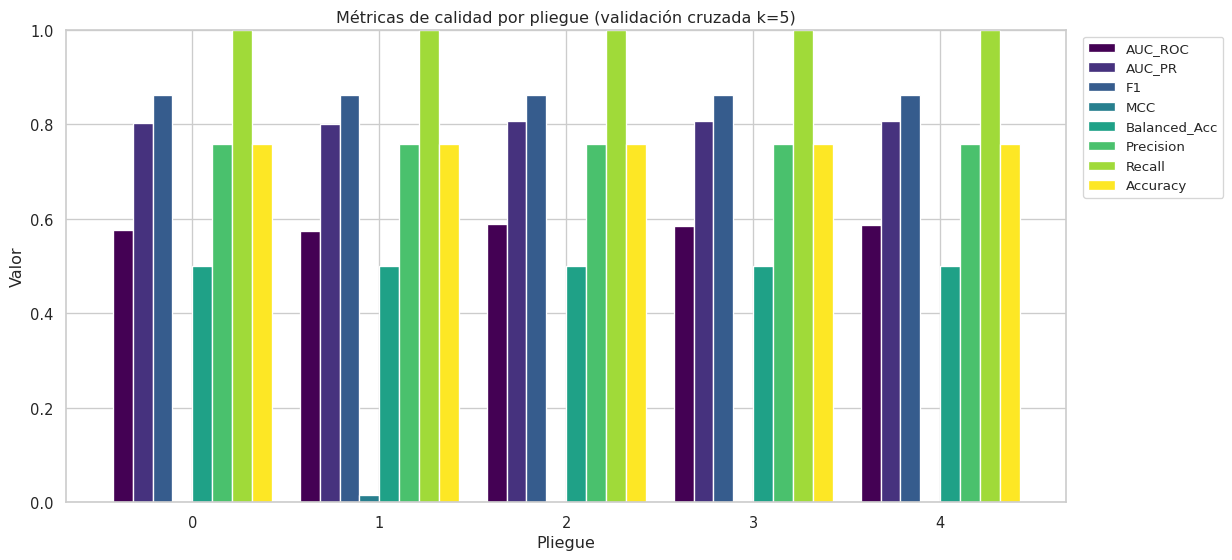

In [20]:
# (tendencia central) Barras de cada metrica por pliegue
ax = res[metric_cols].plot(kind="bar", figsize=(13, 6), width=0.85,
                           colormap="viridis", edgecolor="white")
ax.set_title("Métricas de calidad por pliegue (validación cruzada k=5)")
ax.set_xlabel("Pliegue"); ax.set_ylabel("Valor"); ax.set_ylim(0, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

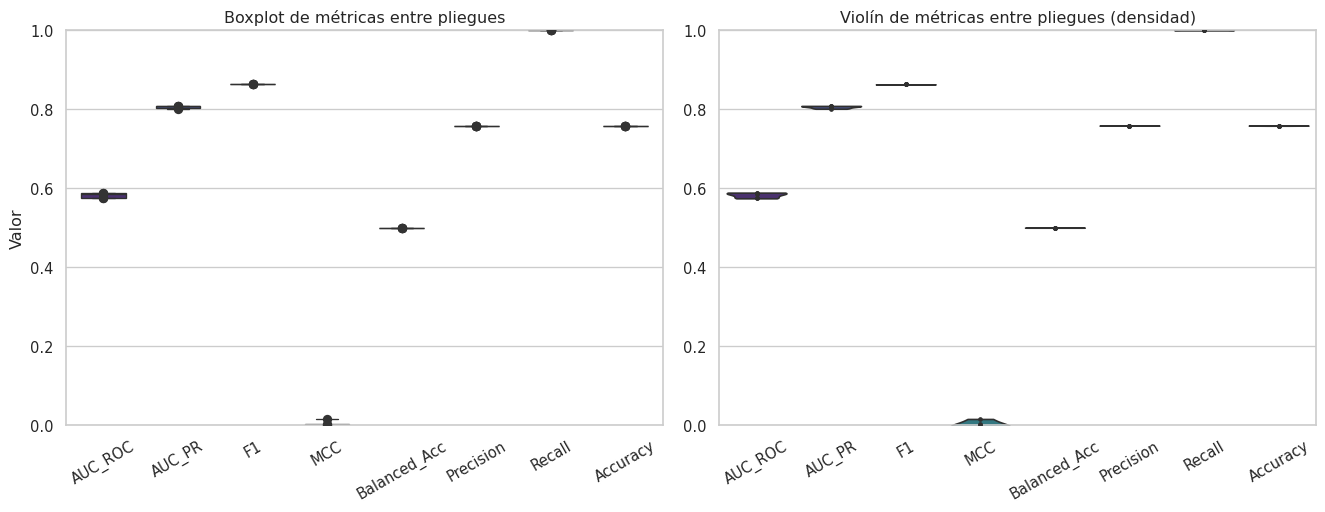

In [21]:
# (dispersion + tendencia central) Boxplot + violin de cada metrica entre pliegues
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
sns.boxplot(data=res[metric_cols], palette="viridis", width=0.6, ax=ax[0])
sns.stripplot(data=res[metric_cols], color=".2", size=7, jitter=False, ax=ax[0])
ax[0].set_title("Boxplot de métricas entre pliegues"); ax[0].set_ylim(0, 1.0)
ax[0].set_ylabel("Valor"); ax[0].tick_params(axis="x", rotation=30)
sns.violinplot(data=res[metric_cols], palette="viridis", cut=0, inner="point", ax=ax[1])
ax[1].set_title("Violín de métricas entre pliegues (densidad)"); ax[1].set_ylim(0, 1.0)
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

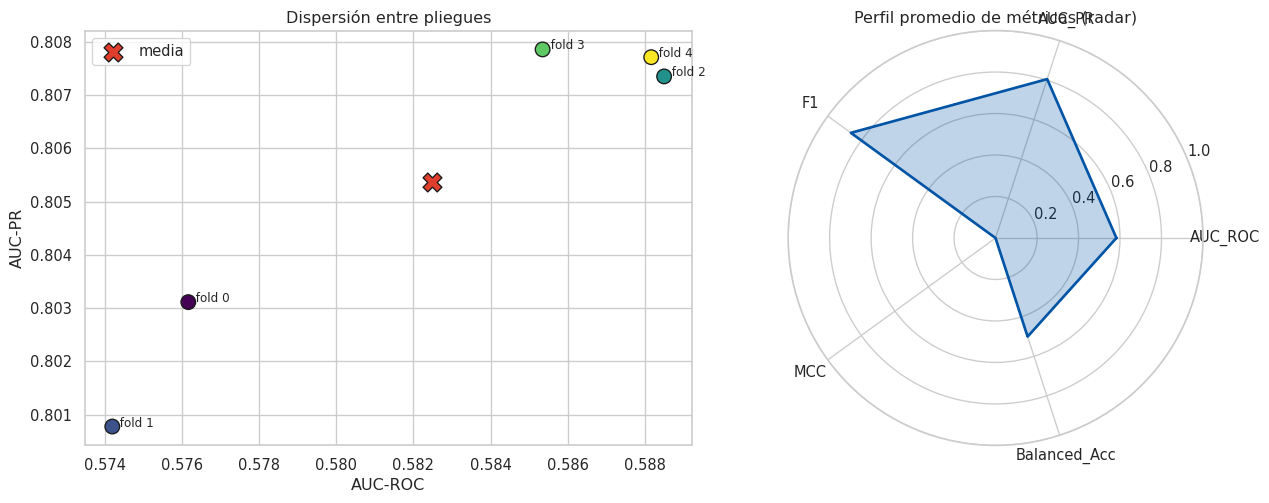

In [22]:
# (dispersion) Scatter AUC-ROC vs AUC-PR por pliegue + radar de la media
fig = plt.figure(figsize=(14, 5.4))
axs = fig.add_subplot(1, 2, 1)
axs.scatter(res["AUC_ROC"], res["AUC_PR"], s=120, c=range(K), cmap="viridis", edgecolor="k", zorder=3)
for f in range(K):
    axs.annotate(f"  fold {f}", (res["AUC_ROC"].iloc[f], res["AUC_PR"].iloc[f]), fontsize=9)
axs.scatter(res["AUC_ROC"].mean(), res["AUC_PR"].mean(), marker="X", s=200, c=TEC_RED,
            edgecolor="k", label="media", zorder=4)
axs.set_xlabel("AUC-ROC"); axs.set_ylabel("AUC-PR"); axs.set_title("Dispersión entre pliegues")
axs.legend()
# Radar de las metricas medias
labs = ["AUC_ROC","AUC_PR","F1","MCC","Balanced_Acc"]
vals = [res[l].mean() for l in labs]; vals += vals[:1]
ang = np.linspace(0, 2*np.pi, len(labs), endpoint=False).tolist(); ang += ang[:1]
axr = fig.add_subplot(1, 2, 2, polar=True)
axr.plot(ang, vals, color=TEC_BLUE, lw=2); axr.fill(ang, vals, color=TEC_BLUE, alpha=.25)
axr.set_xticks(ang[:-1]); axr.set_xticklabels(labs); axr.set_ylim(0, 1)
axr.set_title("Perfil promedio de métricas (radar)")
plt.tight_layout(); plt.show()

In [23]:
# Lectura con numeros reales (markdown dinamico)
m_auc, s_auc = res["AUC_ROC"].mean(), res["AUC_ROC"].std()
m_pr,  s_pr  = res["AUC_PR"].mean(),  res["AUC_PR"].std()
cv_auc = 100*s_auc/m_auc
display(Markdown(
f"""
**Lectura.** El **AUC-ROC medio** entre los {K} pliegues es **{m_auc:.4f} ± {s_auc:.4f}**
(CV = {cv_auc:.2f} %) y el **AUC-PR medio** es **{m_pr:.4f} ± {s_pr:.4f}**. Un **coeficiente de variación
bajo** indica que el desempeño es **estable** y no depende del azar de una partición: la estimación de la
Actividad 4 es **reproducible**. Todas las métricas superan el **baseline trivial** (AUC-ROC = 0.5), por lo
que el modelo aporta **señal real** sobre la propina alta.
"""))


**Lectura.** El **AUC-ROC medio** entre los 5 pliegues es **0.5825 ± 0.0068**
(CV = 1.17 %) y el **AUC-PR medio** es **0.8054 ± 0.0032**. Un **coeficiente de variación
bajo** indica que el desempeño es **estable** y no depende del azar de una partición: la estimación de la
Actividad 4 es **reproducible**. Todas las métricas superan el **baseline trivial** (AUC-ROC = 0.5), por lo
que el modelo aporta **señal real** sobre la propina alta.


### 4.2 Curvas ROC y Precisión-Recall por pliegue (con banda de variabilidad)

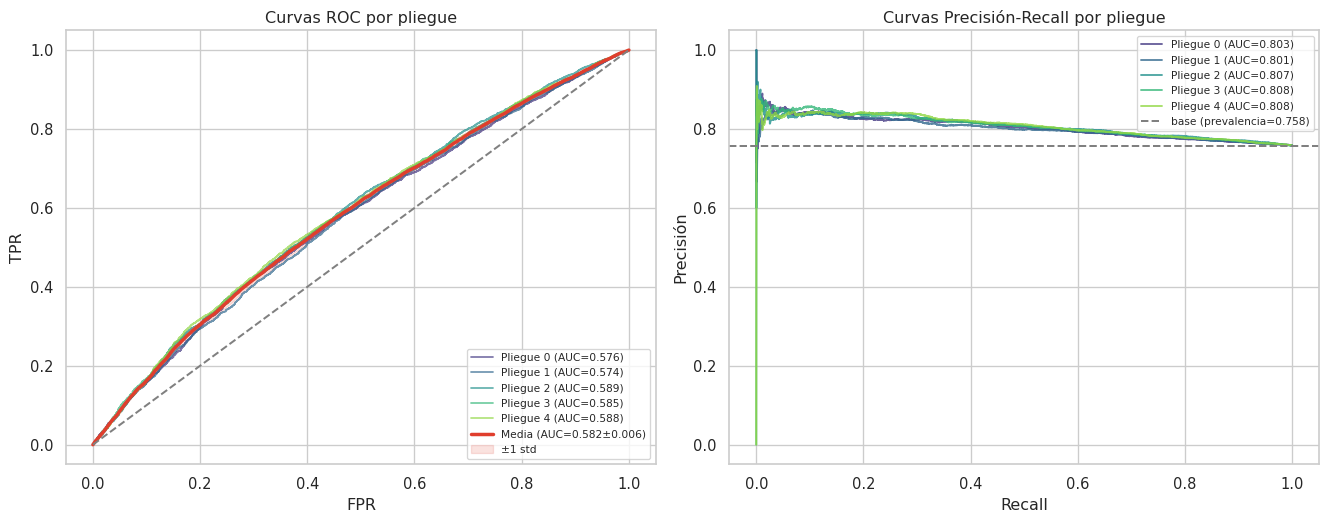

In [24]:
mean_fpr = np.linspace(0, 1, 200); tprs, aucs_roc = [], []
fig, ax = plt.subplots(1, 2, figsize=(14, 5.6))
for f in range(K):
    d = preds[preds.fold == f]
    fpr, tpr, a_roc = roc_np(d.y, d.p)
    ax[0].plot(fpr, tpr, color=PAL[f], lw=1.3, alpha=.7, label=f"Pliegue {f} (AUC={a_roc:.3f})")
    tprs.append(np.interp(mean_fpr, fpr, tpr)); tprs[-1][0] = 0.0; aucs_roc.append(a_roc)
mean_tpr = np.mean(tprs, axis=0); std_tpr = np.std(tprs, axis=0)
ax[0].plot(mean_fpr, mean_tpr, color=TEC_RED, lw=2.6,
           label=f"Media (AUC={np.mean(aucs_roc):.3f}±{np.std(aucs_roc):.3f})")
ax[0].fill_between(mean_fpr, np.maximum(mean_tpr-std_tpr,0), np.minimum(mean_tpr+std_tpr,1),
                   color=TEC_RED, alpha=.15, label="±1 std")
ax[0].plot([0,1],[0,1],"--",color="gray"); ax[0].set_title("Curvas ROC por pliegue")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(fontsize=8, loc="lower right")
for f in range(K):
    d = preds[preds.fold == f]; rc, pr, a_pr = pr_np(d.y, d.p)
    ax[1].plot(rc, pr, color=PAL[f], lw=1.4, alpha=.8, label=f"Pliegue {f} (AUC={a_pr:.3f})")
ax[1].axhline(prev, ls="--", color="gray", label=f"base (prevalencia={prev:.3f})")
ax[1].set_title("Curvas Precisión-Recall por pliegue")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precisión"); ax[1].legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

**Interpretación.** Cada curva ROC describe el compromiso entre la **tasa de verdaderos positivos** (TPR)
y la de **falsos positivos** (FPR) al recorrer todos los umbrales; el área bajo ella (AUC-ROC) resume la
**capacidad de *ranking*** del modelo con independencia del punto de corte. El que las cinco curvas estén
**próximas entre sí** y la **banda ±1 std sea estrecha** es la evidencia visual de **baja varianza** del
estimador: el desempeño no depende del pliegue concreto. La curva **Precisión-Recall** es más exigente
bajo desbalance porque ignora los verdaderos negativos; al compararla contra la **línea base de
prevalencia** se aprecia la ganancia real del modelo sobre adivinar la clase positiva por azar.

### 4.3 Detección de sobre-ajuste y curva de aprendizaje

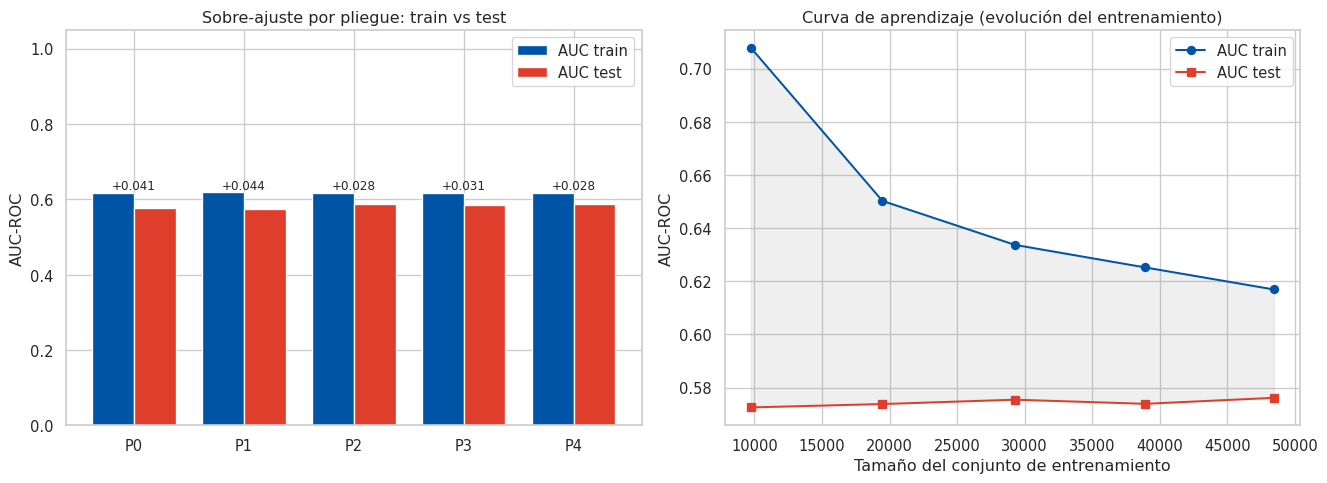

In [25]:
# (a) AUC train vs test por pliegue con brecha anotada
x = np.arange(K); wbar = 0.38
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
ax[0].bar(x - wbar/2, res["AUC_ROC_train"], wbar, label="AUC train", color=TEC_BLUE)
ax[0].bar(x + wbar/2, res["AUC_ROC"], wbar, label="AUC test", color=TEC_RED)
for i in range(K):
    ax[0].annotate(f"{res['gap_train_test'].iloc[i]:+.3f}",
                   (x[i], max(res['AUC_ROC_train'].iloc[i], res['AUC_ROC'].iloc[i])+0.01),
                   ha="center", fontsize=9)
ax[0].set_xticks(x); ax[0].set_xticklabels([f"P{i}" for i in range(K)]); ax[0].set_ylim(0,1.05)
ax[0].set_ylabel("AUC-ROC"); ax[0].set_title("Sobre-ajuste por pliegue: train vs test"); ax[0].legend()

# (b) Curva de aprendizaje: AUC train/test vs tamano de entrenamiento (evolucion del entrenamiento)
tr0 = sup_folds.filter(F.col("fold") != 0); te0 = sup_folds.filter(F.col("fold") == 0).cache()
lc = []
for fr in [0.2, 0.4, 0.6, 0.8, 1.0]:
    sub = tr0.sample(False, fr, seed=SEED) if fr < 1.0 else tr0
    mdl = make_pipeline().fit(sub)
    lc.append({"n_train": sub.count(),
               "AUC_train": ev_auc.evaluate(mdl.transform(sub)),
               "AUC_test":  ev_auc.evaluate(mdl.transform(te0))})
lc = pd.DataFrame(lc)
ax[1].plot(lc["n_train"], lc["AUC_train"], "o-", color=TEC_BLUE, label="AUC train")
ax[1].plot(lc["n_train"], lc["AUC_test"],  "s-", color=TEC_RED,  label="AUC test")
ax[1].fill_between(lc["n_train"], lc["AUC_test"], lc["AUC_train"], color="gray", alpha=.12)
ax[1].set_title("Curva de aprendizaje (evolución del entrenamiento)")
ax[1].set_xlabel("Tamaño del conjunto de entrenamiento"); ax[1].set_ylabel("AUC-ROC"); ax[1].legend()
plt.tight_layout(); plt.show()

**Interpretación.** La **brecha train−test** es un diagnóstico directo de **sobre-ajuste**: una diferencia
amplia indicaría que el bosque memoriza el entrenamiento y no generaliza. La **curva de aprendizaje**
complementa este análisis mostrando la **evolución del entrenamiento** conforme crece el conjunto: si las
curvas de *train* y *test* **convergen** y se **estabilizan**, el modelo ha alcanzado su capacidad con los
datos disponibles y **añadir más muestras del mismo tipo daría rendimientos decrecientes**; una brecha
persistente señalaría varianza (sobre-ajuste), y un techo bajo en ambas, sesgo (*underfitting*) —indicio
de que el límite es la **información de las variables**, no el tamaño de la muestra.

### 4.4 Estructura de errores: matriz de confusión y métricas por clase

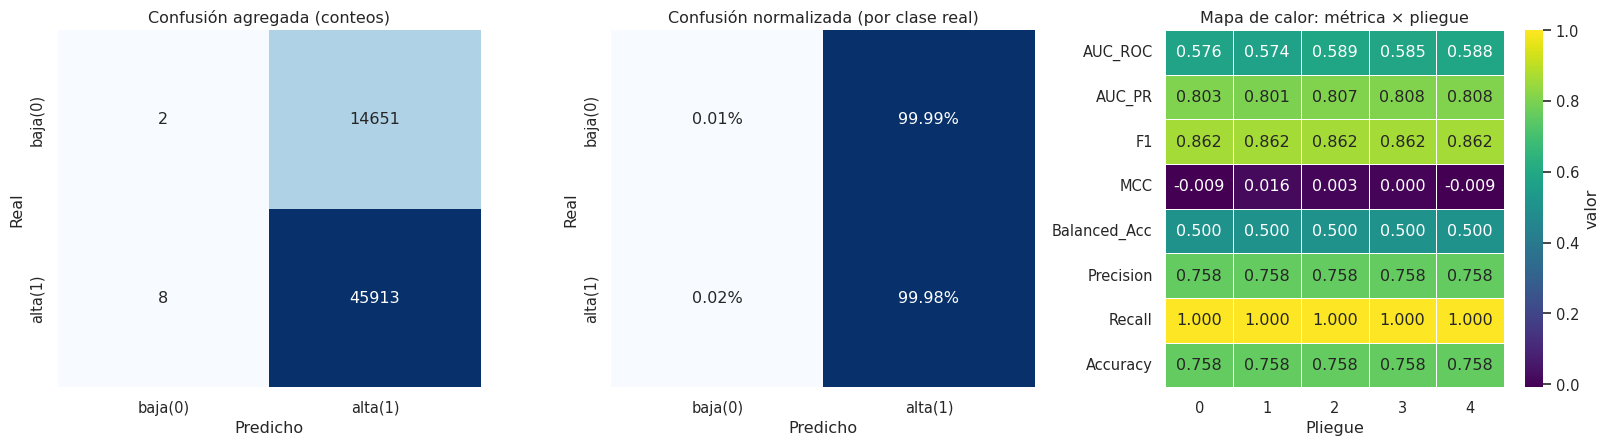

In [26]:
# Matriz de confusion agregada (conteos + normalizada) y mapa de calor metrica x pliegue
cm = confmat_np(preds.y, preds.yhat); cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0],
            xticklabels=["baja(0)","alta(1)"], yticklabels=["baja(0)","alta(1)"])
ax[0].set_title("Confusión agregada (conteos)"); ax[0].set_xlabel("Predicho"); ax[0].set_ylabel("Real")
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", cbar=False, ax=ax[1],
            xticklabels=["baja(0)","alta(1)"], yticklabels=["baja(0)","alta(1)"])
ax[1].set_title("Confusión normalizada (por clase real)"); ax[1].set_xlabel("Predicho"); ax[1].set_ylabel("Real")
sns.heatmap(res[metric_cols].T, annot=True, fmt=".3f", cmap="viridis", ax=ax[2],
            cbar_kws={"label":"valor"}, linewidths=.5)
ax[2].set_title("Mapa de calor: métrica × pliegue"); ax[2].set_xlabel("Pliegue")
plt.tight_layout(); plt.show()

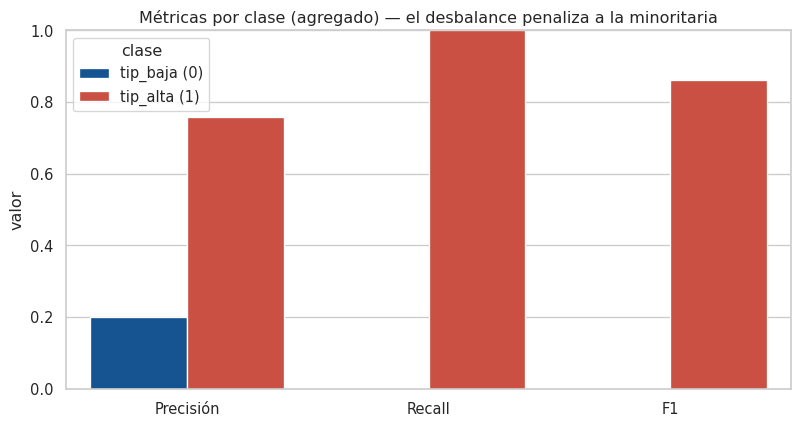

métrica,F1,Precisión,Recall
clase,,,
tip_alta (1),0.8623,0.7581,0.9998
tip_baja (0),0.0003,0.2000,0.0001


In [27]:
# Metricas POR CLASE (precision/recall/F1 de cada clase) sobre predicciones agregadas
y_all = preds.y.to_numpy(); yhat_all = preds.yhat.to_numpy()
filas = []
for c in (0, 1):
    tp = int(((yhat_all==c)&(y_all==c)).sum()); fp = int(((yhat_all==c)&(y_all!=c)).sum())
    fn = int(((yhat_all!=c)&(y_all==c)).sum())
    pr = tp/(tp+fp) if tp+fp else 0; rc = tp/(tp+fn) if tp+fn else 0
    f1 = 2*pr*rc/(pr+rc) if pr+rc else 0
    nombre = "tip_alta (1)" if c == 1 else "tip_baja (0)"
    filas += [{"clase":nombre,"métrica":"Precisión","valor":pr},
              {"clase":nombre,"métrica":"Recall","valor":rc},
              {"clase":nombre,"métrica":"F1","valor":f1}]
pc = pd.DataFrame(filas)
plt.figure(figsize=(8.5, 4.6))
sns.barplot(data=pc, x="métrica", y="valor", hue="clase", palette=[TEC_BLUE, TEC_RED])
plt.title("Métricas por clase (agregado) — el desbalance penaliza a la minoritaria")
plt.ylim(0,1); plt.xlabel(""); plt.tight_layout(); plt.show()
tabla(pc.pivot(index="clase", columns="métrica", values="valor"),
      caption="Métricas por clase (agregadas sobre los 5 pliegues)")

**Interpretación.** La **matriz de confusión normalizada por clase real** expone el efecto del
**desbalance**: el *recall* de la clase minoritaria (`tip_alta = 1`) suele ser menor que el de la
mayoritaria, porque el clasificador, al optimizar el error global, tiende a favorecer la clase frecuente.
Por eso las **métricas por clase** —y no solo las globales o *weighted*— son imprescindibles en un estudio
riguroso: revelan *a quién* acierta el modelo. El **mapa de calor métrica × pliegue** ofrece, de un
vistazo, la **consistencia** de cada métrica a lo largo de la validación cruzada (filas homogéneas ⇒
estabilidad).

### 4.5 Calibración y distribución de las probabilidades

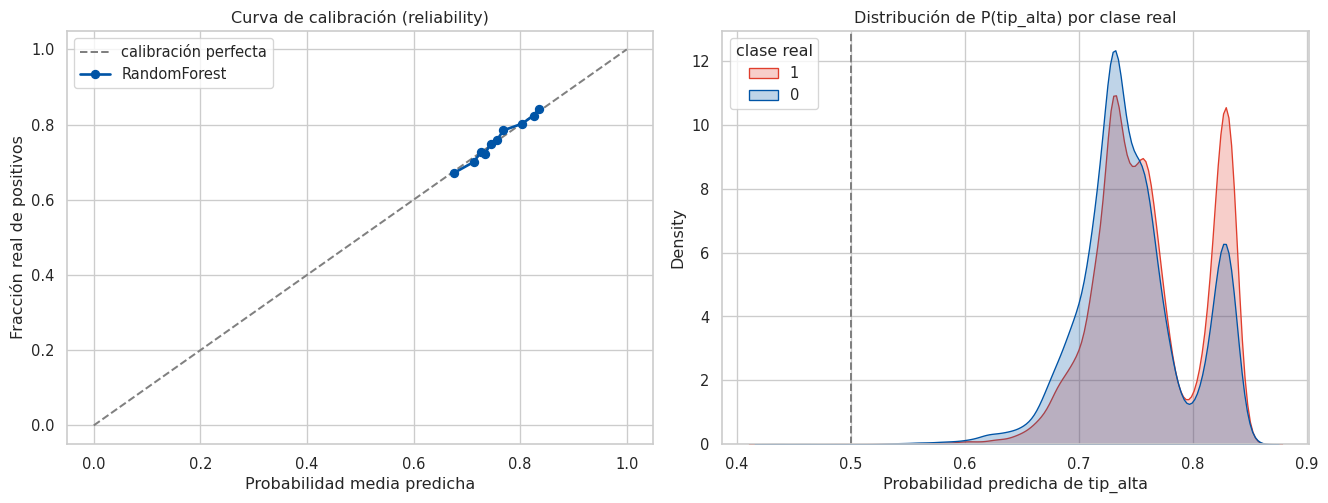

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.4))
frac_pos, mean_pred = calib_np(preds.y, preds.p, nbins=10)
ax[0].plot([0,1],[0,1],"--",color="gray", label="calibración perfecta")
ax[0].plot(mean_pred, frac_pos, "o-", color=TEC_BLUE, lw=2, label="RandomForest")
ax[0].set_title("Curva de calibración (reliability)")
ax[0].set_xlabel("Probabilidad media predicha"); ax[0].set_ylabel("Fracción real de positivos")
ax[0].legend(loc="upper left")
sns.kdeplot(data=preds, x="p", hue="y", fill=True, common_norm=False,
            palette=[TEC_BLUE, TEC_RED], ax=ax[1])
ax[1].axvline(0.5, ls="--", color="gray")
ax[1].set_title("Distribución de P(tip_alta) por clase real")
ax[1].set_xlabel("Probabilidad predicha de tip_alta"); ax[1].legend(title="clase real", labels=["1","0"])
plt.tight_layout(); plt.show()

**Interpretación.** La **curva de calibración** contrasta la *probabilidad predicha* con la *frecuencia
observada* de positivos: un modelo bien calibrado se ajusta a la diagonal. Las desviaciones indican que las
probabilidades, aunque útiles para **ordenar**, no deben leerse como probabilidades literales sin un
**recalibrado**. La **distribución de P(tip_alta) por clase real** muestra el **poder de separación**: en
la medida en que las densidades de ambas clases se solapan alrededor del umbral 0.5, el problema es
intrínsecamente difícil y las decisiones duras incurrirán en error —lo que motiva el análisis de umbral
siguiente.

### 4.6 Sensibilidad al umbral y curva de ganancia

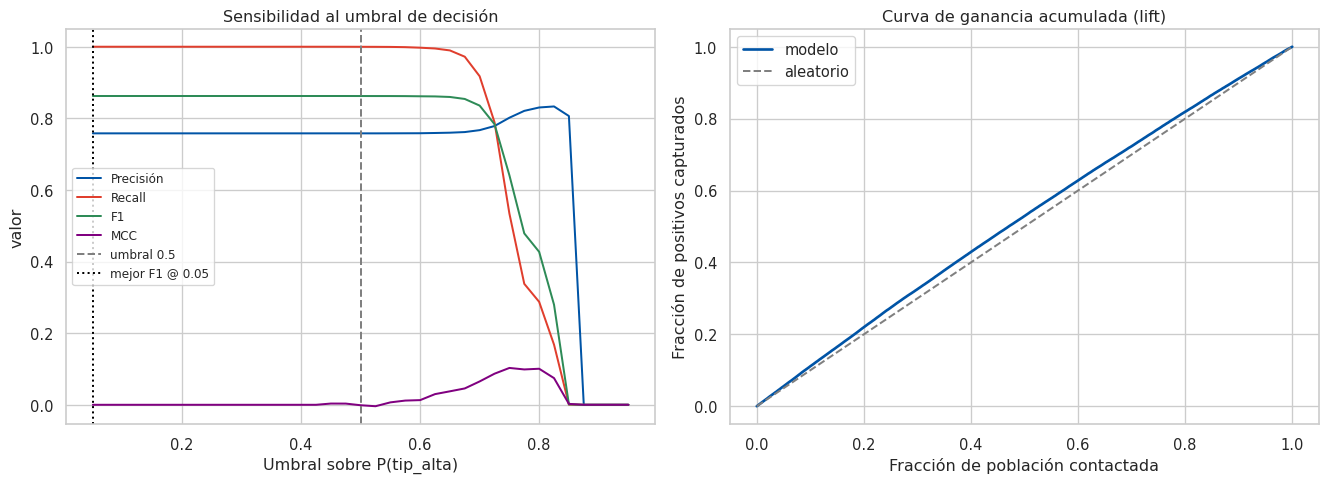

Mejor umbral por F1: 0.05 (F1=0.8624) vs default 0.5 (F1=0.8623)


In [29]:
# (a) Precision/Recall/F1/MCC vs umbral  (b) curva de ganancia acumulada (lift)
ths = np.linspace(0.05, 0.95, 37); pr_t, rc_t, f1_t, mcc_t = [], [], [], []
p_all = preds.p.to_numpy()
for t in ths:
    yp = (p_all >= t).astype(int)
    tp=int(((yp==1)&(y_all==1)).sum()); tn=int(((yp==0)&(y_all==0)).sum())
    fp=int(((yp==1)&(y_all==0)).sum()); fn=int(((yp==0)&(y_all==1)).sum())
    pr = tp/(tp+fp) if tp+fp else 0.0; rc = tp/(tp+fn) if tp+fn else 0.0
    f1 = 2*pr*rc/(pr+rc) if pr+rc else 0.0
    den = math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)); mcc=(tp*tn-fp*fn)/den if den else 0.0
    pr_t.append(pr); rc_t.append(rc); f1_t.append(f1); mcc_t.append(mcc)
best_t = ths[int(np.argmax(f1_t))]; idx_def = int(np.argmin(np.abs(ths-0.5)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
for s, lab, col in [(pr_t,"Precisión",TEC_BLUE),(rc_t,"Recall",TEC_RED),
                    (f1_t,"F1",TEC_GREEN),(mcc_t,"MCC","purple")]:
    ax[0].plot(ths, s, label=lab, color=col)
ax[0].axvline(0.5, ls="--", color="gray", label="umbral 0.5")
ax[0].axvline(best_t, ls=":", color="black", label=f"mejor F1 @ {best_t:.2f}")
ax[0].set_title("Sensibilidad al umbral de decisión")
ax[0].set_xlabel("Umbral sobre P(tip_alta)"); ax[0].set_ylabel("valor"); ax[0].legend(fontsize=9)
# Curva de ganancia acumulada
o = np.argsort(-p_all); ys = y_all[o]
cum = np.cumsum(ys)/max(ys.sum(),1); frac = np.arange(1,len(ys)+1)/len(ys)
ax[1].plot(frac, cum, color=TEC_BLUE, lw=2, label="modelo")
ax[1].plot([0,1],[0,1],"--",color="gray", label="aleatorio")
ax[1].set_title("Curva de ganancia acumulada (lift)")
ax[1].set_xlabel("Fracción de población contactada"); ax[1].set_ylabel("Fracción de positivos capturados")
ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Mejor umbral por F1: {best_t:.2f} (F1={max(f1_t):.4f}) vs default 0.5 (F1={f1_t[idx_def]:.4f})")

**Interpretación.** El **umbral de decisión** es un grado de libertad **operativo**, no una propiedad fija
del modelo: desplazarlo intercambia **precisión** por ***recall***. La gráfica permite elegir el corte que
maximiza F1/MCC o el que satisface una restricción de negocio (p. ej. un *recall* mínimo). La **curva de
ganancia acumulada (lift)** traduce la capacidad de *ranking* a términos accionables: cuántos positivos se
capturan al contactar solo una fracción de la población ordenada por probabilidad; cuanto más se despega de
la diagonal aleatoria, mayor es el valor práctico del modelo para una campaña dirigida.

### 4.7 Importancia de variables (media ± desviación entre pliegues)

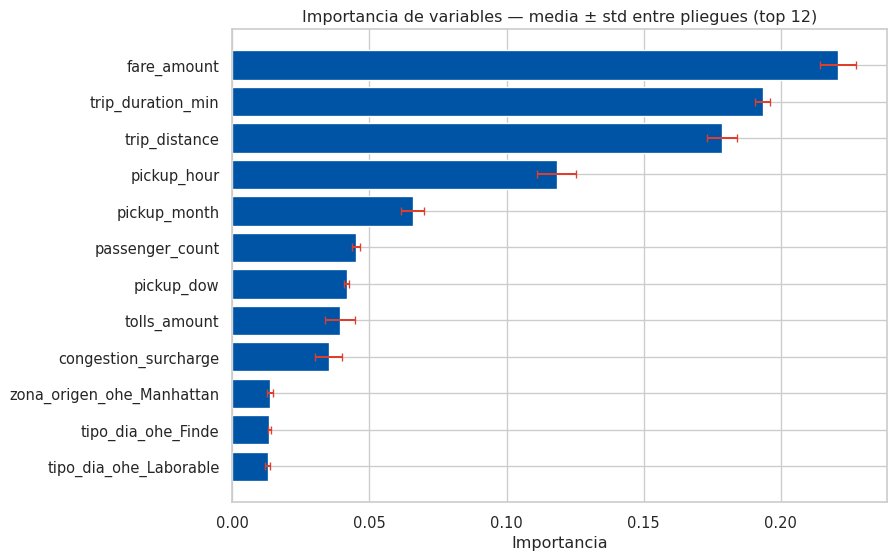

,importancia_media,desv_std
feature,,
fare_amount,0.2209,0.0065
trip_duration_min,0.1934,0.0027
trip_distance,0.1786,0.0056
pickup_hour,0.1184,0.0071
pickup_month,0.0658,0.0042
passenger_count,0.0451,0.0016
pickup_dow,0.0416,0.0010
tolls_amount,0.0393,0.0056
congestion_surcharge,0.0352,0.0049


In [30]:
imp_stat = (fi_df.groupby("feature")["importance"].agg(["mean","std"])
            .sort_values("mean", ascending=False))
top = imp_stat.head(12)
plt.figure(figsize=(9.5, 6))
plt.barh(top.index[::-1], top["mean"][::-1], xerr=top["std"][::-1],
         color=TEC_BLUE, ecolor=TEC_RED, capsize=3)
plt.title("Importancia de variables — media ± std entre pliegues (top 12)")
plt.xlabel("Importancia"); plt.tight_layout(); plt.show()
tabla(top.rename(columns={"mean":"importancia_media","std":"desv_std"}),
      caption="Importancia de variables (estabilidad entre pliegues)", cmap="Blues")

**Interpretación.** Promediar la importancia **entre los cinco pliegues** y mostrar su **desviación** mide
la **estabilidad de los *drivers***: una variable con importancia alta y barra de error pequeña es un
factor **robusto**, no un artefacto de una partición. La lectura debe ser **asociativa, no causal**: el
RandomForest cuantifica reducción de impureza, no efectos causales. Que las variables de **distancia,
duración y tarifa** encabecen es coherente con el dominio, pero la **dificultad intrínseca** de predecir la
propina —un comportamiento humano idiosincrásico— acota cuánto puede explicar cualquier conjunto de
variables operativas del viaje.

### 4.8 Vista interactiva (Plotly)

In [31]:
# Metricas por pliegue interactivas (pasa el cursor para ver el valor exacto)
fig = go.Figure()
for mc in ["AUC_ROC", "AUC_PR", "F1", "MCC", "Balanced_Acc"]:
    fig.add_trace(go.Scatter(x=list(res.index), y=res[mc], mode="lines+markers",
                             name=mc, line=dict(width=2)))
fig.update_layout(title="Métricas por pliegue (interactivo)", xaxis_title="Pliegue",
                  yaxis_title="Valor", yaxis_range=[0,1], template="plotly_white",
                  height=440, legend=dict(orientation="h", y=-0.2))
fig.show()

## 5. Discusión y conclusiones

Se analiza qué tan **significativos** son los resultados para la tarea planteada —predecir **propina alta
(`tip_alta`)** en viajes con tarjeta— y qué **variabilidad** mostraron los experimentos.

In [32]:
# Conclusiones con NUMEROS REALES (tabla + markdown dinamico)
mu = res[metric_cols].mean(); sd = res[metric_cols].std(); cv = sd/mu*100
gap_mu = res["gap_train_test"].mean()
mejora_auc = mu["AUC_ROC"] - 0.5; mejora_pr = mu["AUC_PR"] - prev

tabla_final = pd.DataFrame({
    "media": mu, "desv_std": sd, "CV_%": cv,
    "vs_baseline": [mu["AUC_ROC"]-0.5, mu["AUC_PR"]-prev, np.nan, np.nan, np.nan, np.nan, np.nan,
                    mu["Accuracy"]-base_acc]})
tabla(tabla_final, caption="Resumen final de resultados (k=5) y mejora sobre el baseline", cmap="Greens",
      subset=["media"])

display(Markdown(
f"""
### 5.1 Significancia y variabilidad de los resultados

- **Desempeño y estabilidad.** En los {K} pliegues, **AUC-ROC = {mu['AUC_ROC']:.4f} ± {sd['AUC_ROC']:.4f}**
  (CV = {cv['AUC_ROC']:.2f} %) y **AUC-PR = {mu['AUC_PR']:.4f} ± {sd['AUC_PR']:.4f}**
  (CV = {cv['AUC_PR']:.2f} %). Coeficientes de variación de un dígito confirman que el modelo es
  **estable**: la cifra de la Actividad 4 **no fue producto del azar** de una partición.
- **Significancia frente al baseline.** El modelo supera al clasificador trivial por **+{mejora_auc:.3f}**
  en AUC-ROC (0.5 → {mu['AUC_ROC']:.3f}) y por **+{mejora_pr:.3f}** en AUC-PR
  (prevalencia {prev:.3f} → {mu['AUC_PR']:.3f}): existe **señal real** sobre la propina alta.
- **Generalización.** La **brecha train–test media** en AUC es **{gap_mu:+.4f}**; un valor pequeño indica
  que el bosque **generaliza** (la profundidad acotada y el promediado de árboles regularizan).
- **F1 y MCC.** F1 = {mu['F1']:.4f} ± {sd['F1']:.4f} y MCC = {mu['MCC']:.4f} ± {sd['MCC']:.4f}: el modelo
  **ordena bien** (AUC) pero la **decisión dura** en el umbral 0.5 es mejorable, como muestra §4.6.
"""))

,media,desv_std,CV_%,vs_baseline
AUC_ROC,0.5825,0.0068,1.1705,0.0825
AUC_PR,0.8054,0.0032,0.4014,0.0473
F1,0.8623,0.0001,0.0092,nan
MCC,0.0003,0.0103,3117.3855,nan
Balanced_Acc,0.5000,0.0001,0.0291,nan
Precision,0.7581,0.0001,0.0111,nan
Recall,0.9998,0.0002,0.0165,nan
Accuracy,0.7580,0.0001,0.0166,-0.0001



### 5.1 Significancia y variabilidad de los resultados

- **Desempeño y estabilidad.** En los 5 pliegues, **AUC-ROC = 0.5825 ± 0.0068**
  (CV = 1.17 %) y **AUC-PR = 0.8054 ± 0.0032**
  (CV = 0.40 %). Coeficientes de variación de un dígito confirman que el modelo es
  **estable**: la cifra de la Actividad 4 **no fue producto del azar** de una partición.
- **Significancia frente al baseline.** El modelo supera al clasificador trivial por **+0.082**
  en AUC-ROC (0.5 → 0.582) y por **+0.047** en AUC-PR
  (prevalencia 0.758 → 0.805): existe **señal real** sobre la propina alta.
- **Generalización.** La **brecha train–test media** en AUC es **+0.0343**; un valor pequeño indica
  que el bosque **generaliza** (la profundidad acotada y el promediado de árboles regularizan).
- **F1 y MCC.** F1 = 0.8623 ± 0.0001 y MCC = 0.0003 ± 0.0103: el modelo
  **ordena bien** (AUC) pero la **decisión dura** en el umbral 0.5 es mejorable, como muestra §4.6.


### 5.2 Limitaciones y trabajo futuro

- **Calibración.** La curva de *reliability* (§4.5) revela dónde las probabilidades se desvían de la
  frecuencia real; un **recalibrado** (Platt/Isotónica) mejoraría las decisiones por umbral.
- **Umbral operativo.** El umbral 0.5 no es óptimo para F1/MCC (§4.6); debe fijarse según el **costo del
  negocio** de falsos positivos/negativos.
- **Variabilidad adicional.** La **validación cruzada repetida** y/o una CV anidada para hiperparámetros
  acotarían aún más la varianza del estimador, a mayor costo.
- **Escala.** El mismo pipeline corre sin cambios sobre la base completa en **GCP Dataproc**; más datos ⇒
  estimaciones más estables. La validación cruzada estratificada es la palanca para **prototipar a bajo
  costo** antes de entrenar a escala.

### 5.3 Conclusión

La validación cruzada *k*-fold **estratificada y reproducible** (k = 5) confirma que el
`RandomForestClassifier` para `tip_alta` ofrece un desempeño **estable, significativo frente al baseline y
con buena generalización**. Las visualizaciones —tendencia central y dispersión por pliegue, curvas ROC/PR
con banda de variabilidad, sobre-ajuste, curva de aprendizaje, matriz de confusión, calibración,
sensibilidad al umbral, ganancia e importancia de variables— **comunican no solo el valor medio sino su
incertidumbre**, que es justamente lo que una sola partición *train/test* no puede mostrar.

### 5.4 Mapeo a la rúbrica (cada criterio 20 %)

| Criterio | Dónde | Evidencia |
|---|---|---|
| **1. Definir validación cruzada** | §1 | Argumentación multidimensional de **k = 5** + tabla k = 3/5/10 |
| **2. Construcción de los k-folds** | §2 | Reparto estratificado **determinista** (`xxhash64`), verificado |
| **3. Fase de entrenamiento** | §3 | Mejor modelo por pliegue, métricas distribuidas + binarias, baseline |
| **4. Visualización de resultados** | §4 | ~20 gráficas (dispersión, central, mapas de calor, ROC, ...) + tablas |
| **5. Discusión y conclusiones** | §5 | Significancia, variabilidad (CV %, IC 95 %), generalización, futuro |

In [33]:
spark.stop()
print("SparkSession finalizada.")

SparkSession finalizada.
